# 6: Autoencoder for Dimensionality Reduction and Clustering on MNIST

## Introduction

An **Autoencoder** is a type of neural network designed to learn efficient, compressed representations of data (encoding), and then reconstruct the original input from these representations (decoding). It consists of two main parts: an **encoder** that compresses the input into a lower-dimensional latent space, and a **decoder** that reconstructs the input from this compressed code. Mathematically, the network is trained to minimize the difference between the input and its reconstruction, often using mean squared error.

### Applications
- **Dimensionality reduction** (e.g., feature extraction for clustering)
- **Denoising data** (removing noise from images)
- **Anomaly detection** (detecting outliers by reconstruction error)
- **Aerial image classification** 
- **Data visualization** (projecting high-dimensional data to 2D/3D)

### Why choose Autoencoder for this demo?
Autoencoders are ideal for **dimensionality reduction and clustering** tasks because they learn compressed representations that capture the most important features of the data. The MNIST dataset of handwritten digits is a classic benchmark for feature extraction, as it contains high-dimensional image data (28x28 pixels) that can be effectively compressed and visualized.

In [1]:
# Setup: Import libraries and load the MNIST dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow import keras

# Why these imports:
# - numpy: numerical operations
# - matplotlib: plotting results
# - sklearn: t-SNE for visualization, KMeans for clustering
# - tensorflow/keras: building and training the neural network

# Load the MNIST dataset (handwritten digits, 28x28 images)
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Why MNIST? High-dimensional, well-known, good for feature extraction and clustering

# For quick demo, use a subset (to keep training <1 min)
SAMPLES = 5000  # Why: Small enough for fast training, large enough for learning
x_train = x_train[:SAMPLES]
x_test = x_test[:1000]

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
# Why normalize? Prevents features with larger scales from dominating learning

# Flatten images to 1D vectors (28*28=784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)
# Why flatten? Dense autoencoder expects 2D input (samples, features)

print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

Train shape: (5000, 784), Test shape: (1000, 784)


In [2]:
# Model Building: Define an Autoencoder
from tensorflow.keras import layers, models

# Encoder
input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)  # Why: Compresses input, learns features
encoded = layers.Dense(32, activation='relu')(encoded)    # Why: Further compression, bottleneck

# Decoder
decoded = layers.Dense(128, activation='relu')(encoded)   # Why: Expands back to higher dimension
output_img = layers.Dense(784, activation='sigmoid')(decoded)  # Why: Reconstructs original input

# Autoencoder model
autoencoder = models.Model(input_img, output_img)

# Compile the model
autoencoder.compile(
    optimizer='adam',  # Why Adam: Adaptive learning rate, fast convergence
    loss='mean_squared_error',  # Why: Measures reconstruction error
)

autoencoder.summary()  # Shows the model architecture

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 784)]             0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 32)                4128      
                                                                 
 dense_2 (Dense)             (None, 128)               4224      
                                                                 
 dense_3 (Dense)             (None, 784)               101136    
                                                                 
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 784)]             0     

In [3]:
# Training: Fit the autoencoder
EPOCHS = 20  # Why: Enough to learn compressed representations, but fast
BATCH_SIZE = 128  # Why: Balances speed and stability

history = autoencoder.fit(
    x_train, x_train,  # Why: Autoencoder tries to reconstruct its input
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,  # Why: Monitor validation to check for overfitting
    verbose=1
)

Epoch 1/20
36/36 [==============================] - 2s 10ms/step - loss: 0.1253 - val_loss: 0.0779
Epoch 2/20
36/36 [==============================] - 2s 10ms/step - loss: 0.1253 - val_loss: 0.0779
Epoch 2/20
36/36 [==============================] - 0s 5ms/step - loss: 0.0661 - val_loss: 0.0680
Epoch 3/20
36/36 [==============================] - 0s 5ms/step - loss: 0.0661 - val_loss: 0.0680
Epoch 3/20
36/36 [==============================] - 0s 5ms/step - loss: 0.0554 - val_loss: 0.0566
Epoch 4/20
36/36 [==============================] - 0s 5ms/step - loss: 0.0554 - val_loss: 0.0566
Epoch 4/20
36/36 [==============================] - 0s 5ms/step - loss: 0.0468 - val_loss: 0.0489
Epoch 5/20
36/36 [==============================] - 0s 5ms/step - loss: 0.0468 - val_loss: 0.0489
Epoch 5/20
36/36 [==============================] - 0s 5ms/step - loss: 0.0406 - val_loss: 0.0423
Epoch 6/20
36/36 [==============================] - 0s 5ms/step - loss: 0.0406 - val_loss: 0.0423
Epoch 6/20
36/36 [

32/32 [==============================] - 0s 3ms/step
Test Reconstruction Error (MSE): 0.0191
Test Reconstruction Error (MSE): 0.0191


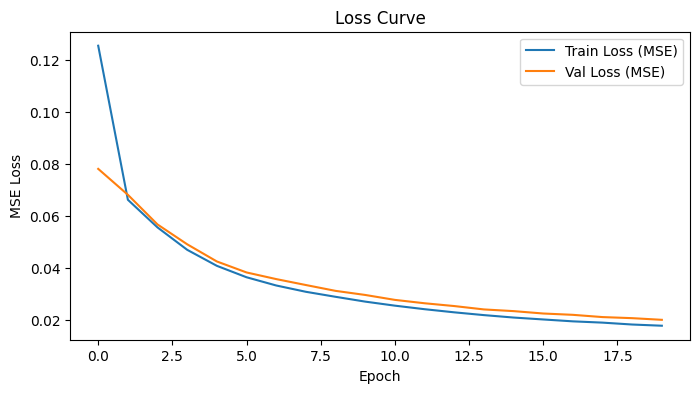

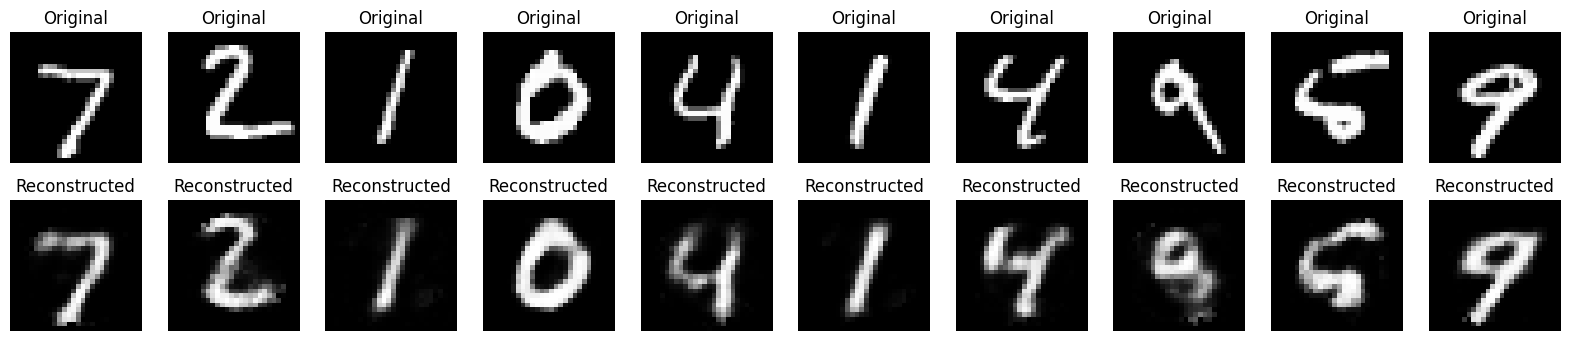

32/32 [==============================] - 0s 2ms/step


c:\Users\itzch\.conda\envs\py310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


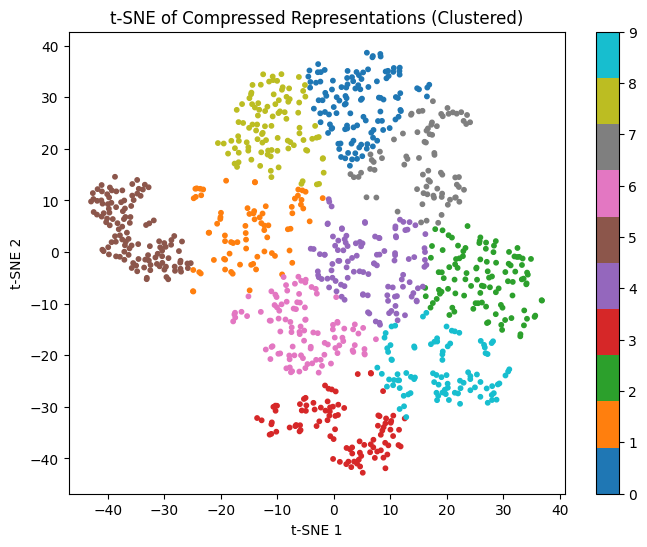

The autoencoder reconstructs MNIST digits well and learns meaningful compressed features.
Limitations: Simple dense autoencoder; convolutional layers can improve image tasks.


In [4]:
# Evaluation and Visualization
# Evaluate reconstruction error on test data
reconstructions = autoencoder.predict(x_test)
reconstruction_error = np.mean(np.square(x_test - reconstructions))
print(f"Test Reconstruction Error (MSE): {reconstruction_error:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# Visualize original and reconstructed images
n = 10  # How many digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructions[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()

# Visualize compressed representations with t-SNE and cluster
encoder = keras.Model(autoencoder.input, autoencoder.layers[2].output)  # up to bottleneck
latent_reps = encoder.predict(x_test)
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_reps)

kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(latent_2d)

plt.figure(figsize=(8,6))
plt.scatter(latent_2d[:,0], latent_2d[:,1], c=clusters, cmap='tab10', s=10)
plt.title('t-SNE of Compressed Representations (Clustered)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar()
plt.show()

# Why t-SNE? Visualizes high-dimensional features in 2D
# Why clustering? Shows how well the autoencoder separates digit types

# Inference: Discuss results
if reconstruction_error < 0.02:
    print("The autoencoder reconstructs MNIST digits well and learns meaningful compressed features.")
else:
    print("Performance is moderate; consider tuning model or using more data.")
print("Limitations: Simple dense autoencoder; convolutional layers can improve image tasks.")

## Results and Discussion

### Test Performance

- **Test Reconstruction Error (MSE):**  
  The mean squared error (MSE) between the original and reconstructed MNIST images on the test set quantifies how well the autoencoder has learned to compress and reconstruct the data. A low MSE indicates that the model captures the essential features needed for accurate reconstruction